In [2]:
library(dplyr)
library(tidyr)
library(readxl)
library(openxlsx)
library(ggrepel)
library(limma)
library(cowplot)
library(tools)
library(snowfall)

# DEG: merge and statistics

In [3]:
merge_result = read.csv('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/Classification_L3_edgeR_agegroup_lfc_summarise.csv',row.names = 1)

In [5]:
merge_result

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,ASDC,10_19vs2_9,0,672,0,672
2,ASDC,20_29vs10_19,15,644,13,672
3,ASDC,30_39vs20_29,0,672,0,672
4,ASDC,40_49vs30_39,0,672,0,672
5,ASDC,50_59vs40_49,0,672,0,672
6,ASDC,60_69vs50_59,2,662,8,672
7,ASDC,70_79vs60_69,0,672,0,672
8,ASDC,80_89vs70_79,0,672,0,672
9,ASDC,90_vs80_89,0,672,0,672


In [6]:
plot_data = merge_result %>% mutate(up_ratio = Up / Background_gene_count,
                                    down_ratio = Down / Background_gene_count,
                                    down_ratio_neg = - down_ratio,
                                   Down_neg = -Down)#  %>% subset(grepl('NDN',cell_type)) # %>%  filter(up_ratio > 0.01 | down_ratio > 0.01)

## Num

In [7]:
plot_data <- plot_data %>%
  select(cell_type, pair, Up, Down_neg) %>%
  pivot_longer(cols = c(Up, Down_neg),
               names_to = "change_type",
               values_to = "DEG_num") %>%
  mutate(
    change_direction = ifelse(change_type == "Up", "0Up-regulation", "1Down-regulation")
  )

In [21]:
plot_data$pair = factor(plot_data$pair,levels = c('10_19vs2_9','20_29vs10_19','30_39vs20_29','40_49vs30_39',
                                                  '50_59vs40_49','60_69vs50_59','70_79vs60_69','80_89vs70_79','90_vs80_89'))

plot_data$cell_type = factor(plot_data$cell_type,levels = c('ASDC','LAMP3pos_DC','cDC1','cDC2','pDCs',
                                                            
                                                            'Naïve_B_cells','Atypical_B_cells','Memory_B_cells','Plasma_cells',
                                                            
                                                            'DN_T_cells',
                                                            'Naïve_CD4pos_T_cells',
                                                            'Help_memory_T_cells',
                                                            'Cytotoxic_CD4pos_T_cells',
                                                            'CD4pos_Treg','CD8pos_Treg',
                                                            
                                                            'Naïve_CD8pos_T_cells','CD8pos_Tcm','CD8pos_Tem',
                                                            'MAIT','NKT',
                                                            'Vδ1pos_T_cells','Vδ2pos_T_cells',
                                                            'NK_cells','Non_NK_ILCs',
                                                            'HSPC',
                                                            'Classical_monocytes','Intermediate_monocytes','Non_classical_Monocytes',
                                                            
                                                            'LDNs','NDNs','Basophils','Mast_cells',
                                                            
                                                            'Platelets'
))

In [22]:
head(plot_data)

cell_type,pair,change_type,DEG_num,change_direction
<fct>,<fct>,<chr>,<int>,<chr>
ASDC,10_19vs2_9,Up,0,0Up-regulation
ASDC,10_19vs2_9,Down_neg,0,1Down-regulation
ASDC,20_29vs10_19,Up,13,0Up-regulation
ASDC,20_29vs10_19,Down_neg,-15,1Down-regulation
ASDC,30_39vs20_29,Up,0,0Up-regulation
ASDC,30_39vs20_29,Down_neg,0,1Down-regulation


In [25]:
custom_theme <- theme_cowplot+
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    #legend.position = 'none',
    strip.text = element_text(size = 11, face = "bold")
  )

p = ggplot(plot_data, aes(x =cell_type, y = DEG_num, fill = pair)) +
 
  geom_col(position = position_dodge(width = 0.8, preserve = "total"), width =0.8) +

  scale_fill_manual(values =c(c('#4169E1', '#EE934E', '#3CB371', '#9370DB', '#F8D7DA', '#8AD9DF', '#8B5A2B', '#BBDD78', '#4682B4', '#CD853F'))) + 
  facet_grid(. ~ cell_type, scales = "free_x", space = "free_x") +
  custom_theme

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ1pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ2pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ1pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ2pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”


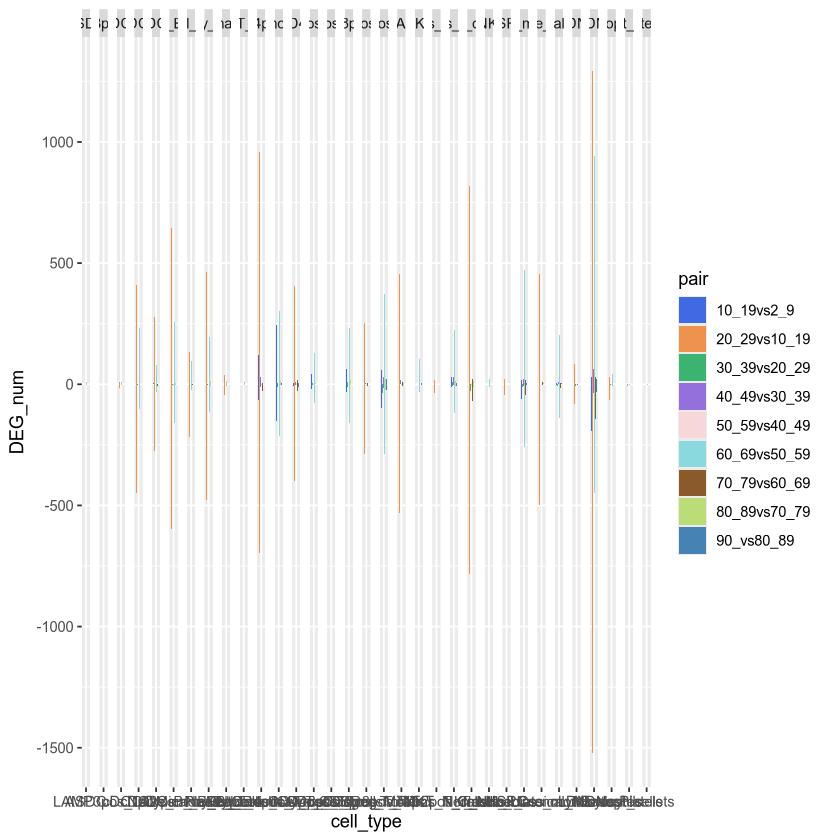

In [30]:
p
ggsave2('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/DEG_num.pdf',p,width=8,height=3)

## Ratio

In [27]:
plot_data <- plot_data %>%
  select(cell_type, pair, up_ratio, down_ratio_neg) %>%
  pivot_longer(cols = c(up_ratio, down_ratio_neg),
               names_to = "change_type",
               values_to = "ratio") %>%
  mutate(
    change_direction = ifelse(change_type == "up_ratio", "0Up-regulation", "1Down-regulation")
  )

In [28]:
table(plot_data$cell_type)


                    ASDC         Atypical_B_cells                Basophils 
                      18                       18                       18 
             CD4pos_Treg               CD8pos_Tcm               CD8pos_Tem 
                      18                       18                       18 
             CD8pos_Treg                     cDC1                     cDC2 
                      18                       18                       18 
     Classical_monocytes Cytotoxic_CD4pos_T_cells               DN_T_cells 
                      18                       18                       18 
     Help_memory_T_cells                     HSPC   Intermediate_monocytes 
                      18                       18                       18 
             LAMP3pos_DC                     LDNs                     MAIT 
                      18                       18                       18 
              Mast_cells           Memory_B_cells            Naïve_B_cells 
           

In [29]:
plot_data$pair = factor(plot_data$pair,levels = c('10_19vs2_9','20_29vs10_19','30_39vs20_29','40_49vs30_39',
                                                  '50_59vs40_49','60_69vs50_59','70_79vs60_69','80_89vs70_79','90_vs80_89'))

#plot_data$cell_type = factor(plot_data$cell_type,levels = c('Aged_NDNs','Core_NDNs','CXCL8__NDNs','FOS__NDNs','IRF1__NDNs','RGS2__NDNs'))

In [30]:
plot_data = plot_data[order((plot_data$ratio),decreasing = T),]

In [35]:
head(plot_data)

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count,up_ratio,down_ratio,down_ratio_neg,DEG_num
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
1,ASDC,10_19vs2_9,0,672,0,672,0.00000000,0.00000000,0.00000000,0
2,ASDC,20_29vs10_19,15,644,13,672,0.01934524,0.02232143,-0.02232143,28
3,ASDC,30_39vs20_29,0,672,0,672,0.00000000,0.00000000,0.00000000,0
4,ASDC,40_49vs30_39,0,672,0,672,0.00000000,0.00000000,0.00000000,0
5,ASDC,50_59vs40_49,0,672,0,672,0.00000000,0.00000000,0.00000000,0
6,ASDC,60_69vs50_59,2,662,8,672,0.01190476,0.00297619,-0.00297619,10


In [21]:
custom_theme <- theme_bw()+
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    #legend.position = 'none',
    strip.text = element_text(size = 11, face = "bold")
  )
p = ggplot(plot_data, aes(x = cell_type, y = ratio, fill = pair)) +
 
  geom_col(position = position_dodge(width = 0.8,preserve = "total"), width =0.8) +

  scale_fill_manual(values =c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371'))+
  custom_theme

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ1pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Vδ2pos_T_cells' in 'mbcsToSbcs': for δ (U+03B4)”


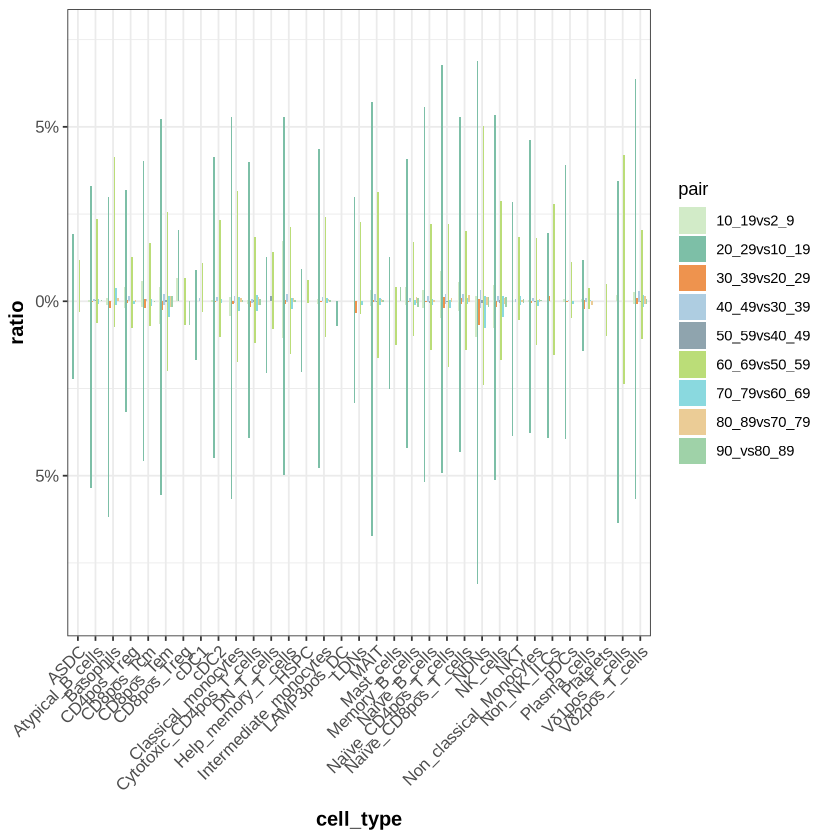

In [23]:
p
ggsave2('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/DEG_ratio.pdf',p,width=20,height=8)

### Bas

In [68]:
merge_result = read.csv('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR/Classification_L4_edgeR_agegroup_lfc_summarise.csv',row.names = 1)

In [69]:
head(merge_result)

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,Adaptive_NK_cells,10_19vs2_9,4,11301,1,11306
2,Adaptive_NK_cells,20_29vs10_19,67,11208,31,11306
3,Adaptive_NK_cells,30_39vs20_29,6,11300,0,11306
4,Adaptive_NK_cells,40_49vs30_39,0,11306,0,11306
5,Adaptive_NK_cells,50_59vs40_49,0,11306,0,11306
6,Adaptive_NK_cells,60_69vs50_59,4,11258,44,11306


In [71]:
plot_data = merge_result %>% mutate(up_ratio = Up / Background_gene_count,
                                    down_ratio = Down / Background_gene_count,
                                    down_ratio_neg = - down_ratio)  %>% subset(grepl('Bas',cell_type)) # %>%  filter(up_ratio > 0.01 | down_ratio > 0.01)

In [72]:
plot_data <- plot_data %>%
  select(cell_type, pair, up_ratio, down_ratio_neg) %>%
  pivot_longer(cols = c(up_ratio, down_ratio_neg),
               names_to = "change_type",
               values_to = "ratio") %>%
  mutate(
    change_direction = ifelse(change_type == "up_ratio", "0Up-regulation", "1Down-regulation")
  )

In [73]:
table(plot_data$cell_type)


Basophils 
       18 

In [77]:
plot_data$pair = factor(plot_data$pair,levels = c('10_19vs2_9','20_29vs10_19','30_39vs20_29','40_49vs30_39',
                                                  '50_59vs40_49','60_69vs50_59','70_79vs60_69','80_89vs70_79','90_vs80_89'))

In [78]:
plot_data = plot_data[order((plot_data$ratio),decreasing = T),]

In [79]:
#代表谁的差异分组最多
table(plot_data$cell_type)


  Aged_NDNs   Core_NDNs CXCL8__NDNs   FOS__NDNs  IRF1__NDNs  RGS2__NDNs 
          0           0           0           0           0           0 

In [80]:
custom_theme <- theme_bw()+
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    #legend.position = 'none',
    strip.text = element_text(size = 11, face = "bold")
  )
p = ggplot(plot_data, aes(x =cell_type, y = ratio, fill = pair)) +
 
  geom_col(position = position_dodge(width = 0.8,preserve = "total"), width =0.8) +

  scale_fill_manual(values =c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371')) +
  scale_y_continuous(
    labels = function(x) ifelse(x > 0, paste0(x*100, "%"), paste0(-x*100, "%")),
    expand = expansion(mult = c(0.1,0.1))
  ) +
  custom_theme

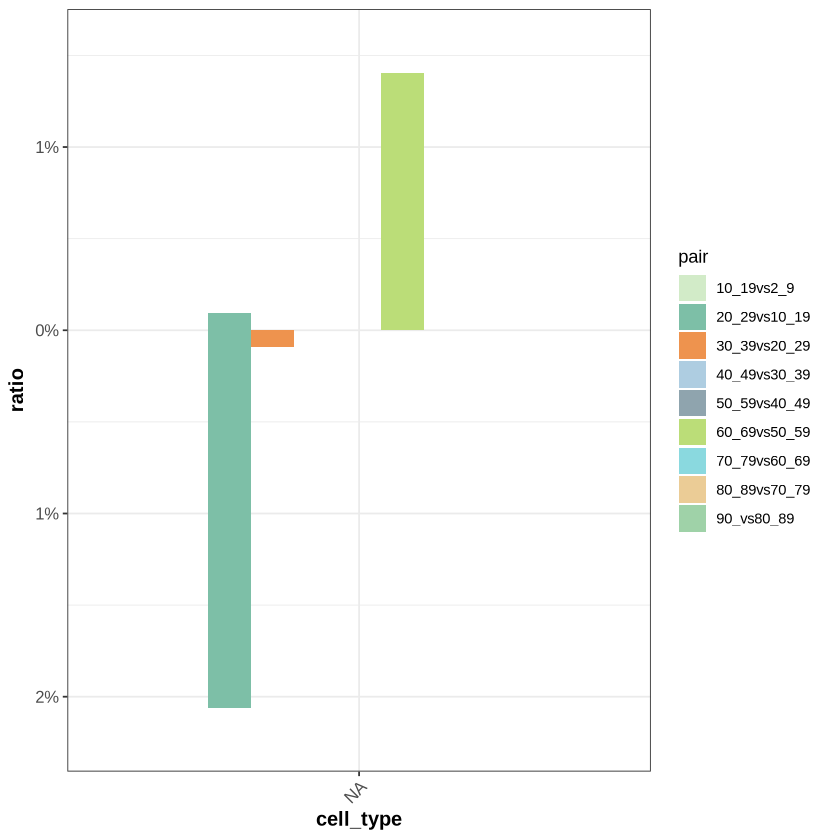

In [82]:
p
ggsave2('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR/Bas_DEG_ratio.pdf',p,width=10,height=8)

### NDNs

In [43]:
specific_cell_type = 'NDNs'

In [44]:
merge_result = read.csv('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/Classification_L3_edgeR_agegroup_lfc_summarise.csv',row.names = 1)

In [45]:
head(merge_result)

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,ASDC,10_19vs2_9,0,672,0,672
2,ASDC,20_29vs10_19,15,644,13,672
3,ASDC,30_39vs20_29,0,672,0,672
4,ASDC,40_49vs30_39,0,672,0,672
5,ASDC,50_59vs40_49,0,672,0,672
6,ASDC,60_69vs50_59,2,662,8,672


In [46]:
plot_data = merge_result %>% mutate(up_ratio = Up / Background_gene_count,
                                    down_ratio = Down / Background_gene_count,
                                    down_ratio_neg = - down_ratio)  %>% subset(grepl(specific_cell_type,cell_type))

In [47]:
plot_data

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count,up_ratio,down_ratio,down_ratio_neg
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
208,NDNs,10_19vs2_9,194,18565,30,18789,0.0015966789,0.010325190,-0.010325190
209,NDNs,20_29vs10_19,1523,15974,1292,18789,0.0687636383,0.081058066,-0.081058066
210,NDNs,30_39vs20_29,127,18652,10,18789,0.0005322263,0.006759274,-0.006759274
211,NDNs,40_49vs30_39,36,18690,63,18789,0.0033530257,0.001916015,-0.001916015
212,NDNs,50_59vs40_49,8,18773,8,18789,0.0004257810,0.000425781,-0.000425781
213,NDNs,60_69vs50_59,450,17396,943,18789,0.0501889403,0.023950184,-0.023950184
214,NDNs,70_79vs60_69,144,18614,31,18789,0.0016499015,0.007664059,-0.007664059
215,NDNs,80_89vs70_79,19,18747,23,18789,0.0012241205,0.001011230,-0.001011230
216,NDNs,90_vs80_89,31,18737,21,18789,0.0011176752,0.001649902,-0.001649902


In [54]:
450+943

[1] 1393

In [36]:
plot_data <- plot_data %>%
  select(cell_type, pair, up_ratio, down_ratio_neg) %>%
  pivot_longer(cols = c(up_ratio, down_ratio_neg),
               names_to = "change_type",
               values_to = "ratio") %>%
  mutate(
    change_direction = ifelse(change_type == "up_ratio", "0Up-regulation", "1Down-regulation")
  )

In [37]:
table(plot_data$cell_type)


NDNs 
  18 

In [38]:
plot_data$pair = factor(plot_data$pair,levels = c('10_19vs2_9','20_29vs10_19','30_39vs20_29','40_49vs30_39',
                                                  '50_59vs40_49','60_69vs50_59','70_79vs60_69','80_89vs70_79','90_vs80_89'))
#plot_data$cell_type = factor(plot_data$cell_type,levels = c('Aged_NDNs','Core_NDNs','CXCL8__NDNs','FOS__NDNs','IRF1__NDNs','RGS2__NDNs'))

In [39]:
plot_data = plot_data[order((plot_data$ratio),decreasing = T),]

In [40]:
custom_theme <- theme_bw()+
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    #legend.position = 'none',
    strip.text = element_text(size = 11, face = "bold")
  )
p = ggplot(plot_data, aes(x =cell_type, y = ratio, fill = pair)) +
 
  geom_col(position = position_dodge(width = 0.8,preserve = "total"), width =0.8) +

  scale_fill_manual(values =c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371')) +
  scale_y_continuous(
    labels = function(x) ifelse(x > 0, paste0(x*100, "%"), paste0(-x*100, "%")),
    expand = expansion(mult = c(0.1,0.1))
  ) +
  custom_theme

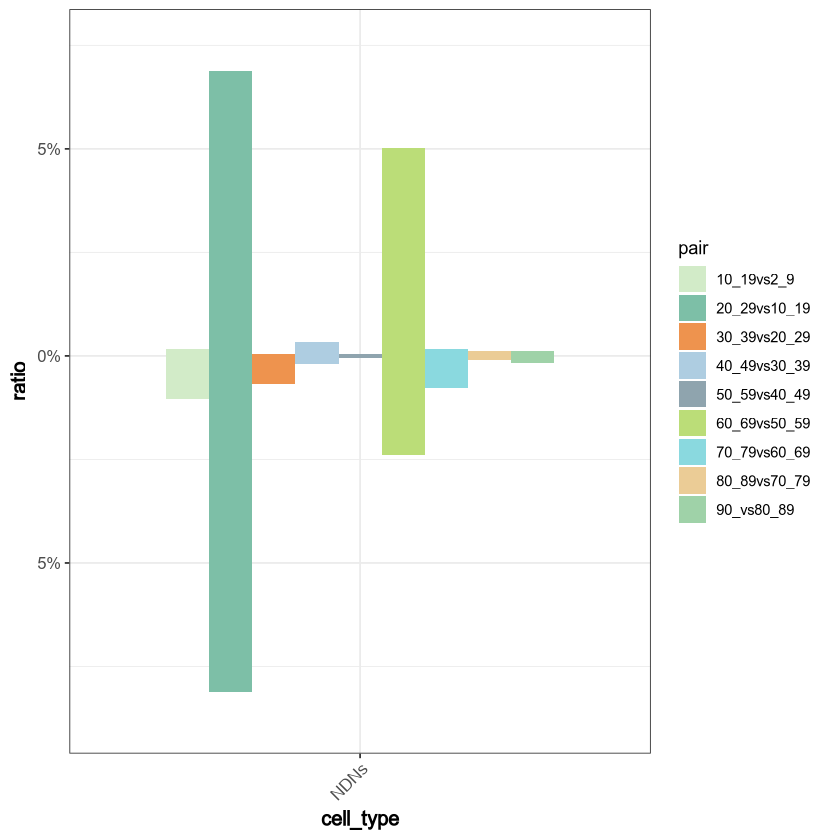

In [42]:
p
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/',specific_cell_type,'_DEG_ratio.pdf'),p,width=10,height=8)

### LDNs

In [48]:
specific_cell_type = 'LDNs'

In [49]:
merge_result = read.csv('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/Classification_L3_edgeR_agegroup_lfc_summarise.csv',row.names = 1)

In [50]:
head(merge_result)

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,ASDC,10_19vs2_9,0,672,0,672
2,ASDC,20_29vs10_19,15,644,13,672
3,ASDC,30_39vs20_29,0,672,0,672
4,ASDC,40_49vs30_39,0,672,0,672
5,ASDC,50_59vs40_49,0,672,0,672
6,ASDC,60_69vs50_59,2,662,8,672


In [51]:
plot_data = merge_result %>% mutate(up_ratio = Up / Background_gene_count,
                                    down_ratio = Down / Background_gene_count,
                                    down_ratio_neg = - down_ratio)  %>% subset(grepl(specific_cell_type,cell_type))

In [52]:
plot_data

,cell_type,pair,Down,NotSignificant,Up,Background_gene_count,up_ratio,down_ratio,down_ratio_neg
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
145,LDNs,10_19vs2_9,0,2745,0,2745,0.00000000,0.000000000,0.000000000
146,LDNs,20_29vs10_19,80,2583,82,2745,0.02987250,0.029143898,-0.029143898
147,LDNs,30_39vs20_29,9,2736,0,2745,0.00000000,0.003278689,-0.003278689
148,LDNs,40_49vs30_39,0,2745,0,2745,0.00000000,0.000000000,0.000000000
149,LDNs,50_59vs40_49,0,2745,0,2745,0.00000000,0.000000000,0.000000000
150,LDNs,60_69vs50_59,10,2673,62,2745,0.02258652,0.003642987,-0.003642987
151,LDNs,70_79vs60_69,3,2742,0,2745,0.00000000,0.001092896,-0.001092896
152,LDNs,80_89vs70_79,0,2745,0,2745,0.00000000,0.000000000,0.000000000
153,LDNs,90_vs80_89,0,2745,0,2745,0.00000000,0.000000000,0.000000000


In [36]:
plot_data <- plot_data %>%
  select(cell_type, pair, up_ratio, down_ratio_neg) %>%
  pivot_longer(cols = c(up_ratio, down_ratio_neg),
               names_to = "change_type",
               values_to = "ratio") %>%
  mutate(
    change_direction = ifelse(change_type == "up_ratio", "0Up-regulation", "1Down-regulation")
  )

In [37]:
table(plot_data$cell_type)


NDNs 
  18 

In [38]:
plot_data$pair = factor(plot_data$pair,levels = c('10_19vs2_9','20_29vs10_19','30_39vs20_29','40_49vs30_39',
                                                  '50_59vs40_49','60_69vs50_59','70_79vs60_69','80_89vs70_79','90_vs80_89'))
#plot_data$cell_type = factor(plot_data$cell_type,levels = c('Aged_NDNs','Core_NDNs','CXCL8__NDNs','FOS__NDNs','IRF1__NDNs','RGS2__NDNs'))

In [39]:
plot_data = plot_data[order((plot_data$ratio),decreasing = T),]

In [40]:
custom_theme <- theme_bw()+
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1,vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    #legend.position = 'none',
    strip.text = element_text(size = 11, face = "bold")
  )
p = ggplot(plot_data, aes(x =cell_type, y = ratio, fill = pair)) +
 
  geom_col(position = position_dodge(width = 0.8,preserve = "total"), width =0.8) +

  scale_fill_manual(values =c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371')) +
  scale_y_continuous(
    labels = function(x) ifelse(x > 0, paste0(x*100, "%"), paste0(-x*100, "%")),
    expand = expansion(mult = c(0.1,0.1))
  ) +
  custom_theme

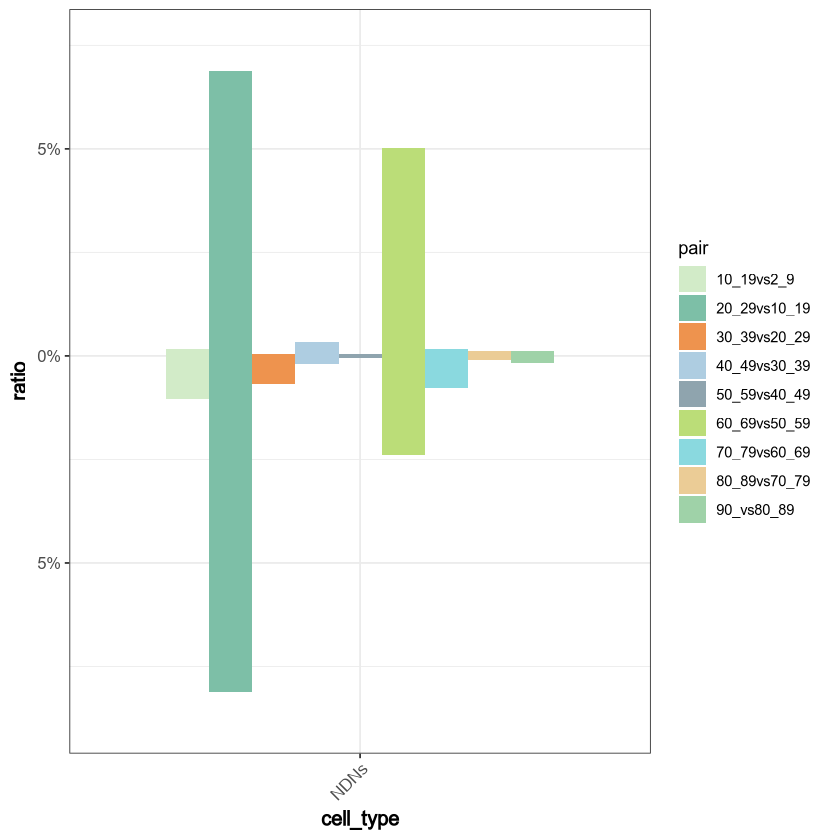

In [42]:
p
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/',specific_cell_type,'_DEG_ratio.pdf'),p,width=10,height=8)

# Global Analysis of DEG in age group with 分组散点图

In [89]:
merge_df2 = subset(merge_df,direction != 'NotSignificant')

In [90]:
plot_data = merge_df2 %>%
    filter(Classification_L4 == 'Th22')
dim(plot_data)

[1] 83378    13

In [92]:
head(plot_data)

,Classification_L4,Classification_L3,Classification_L2,Classification_L1,pair,gene,log2FoldChange,padj,direction,baseMean,lfcSE,stat,pvalue
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,MAP3K8,0.9472903,1.726440e-28,Up,20.52985,0.07967261,11.88979,1.337496e-32
2,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,CBX4,0.9363739,1.520099e-23,Up,12.53864,0.08642297,10.83478,2.355282e-27
3,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,H3-3B,0.4125834,2.412659e-21,Up,216.56130,0.03997147,10.32195,5.607357e-25
4,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,IRF4,1.2325556,2.390995e-20,Up,51.05336,0.12250944,10.06090,8.224036e-24
5,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,TXNRD1,0.7754010,2.390995e-20,Up,27.22016,0.07716048,10.04920,9.261680e-24
6,Th22,Help memory T cells,CD4+ T cells,T cells,2_9_vs_30_39,FGD2,-0.5757582,8.485462e-20,Down,34.31730,0.05812575,-9.90539,3.944280e-23


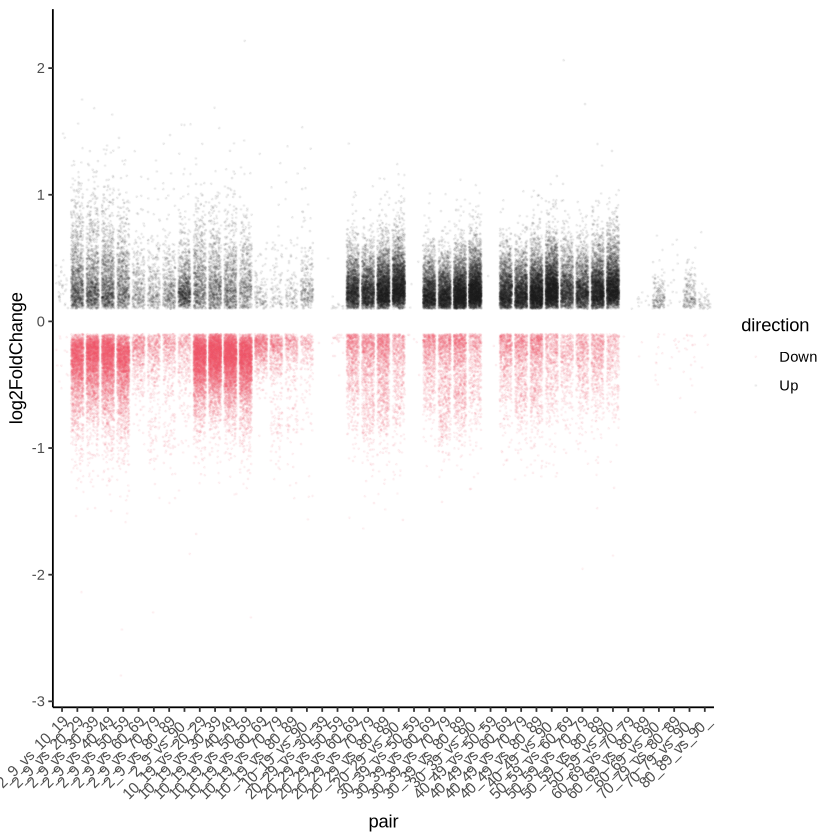

In [104]:
#https://mp.weixin.qq.com/s/soILPMebs6VQPccvt8igFg
ggplot(plot_data) + 
    geom_jitter(aes(x = pair, y = log2FoldChange, color = direction),size = 0.2, width =0.4,alpha=0.05) + 
    scale_color_manual(values = c("#f05f63","#1b1b1b")) + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 45,hjust = 1))